In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f


/tmp/ipykernel_3044869/953547125.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


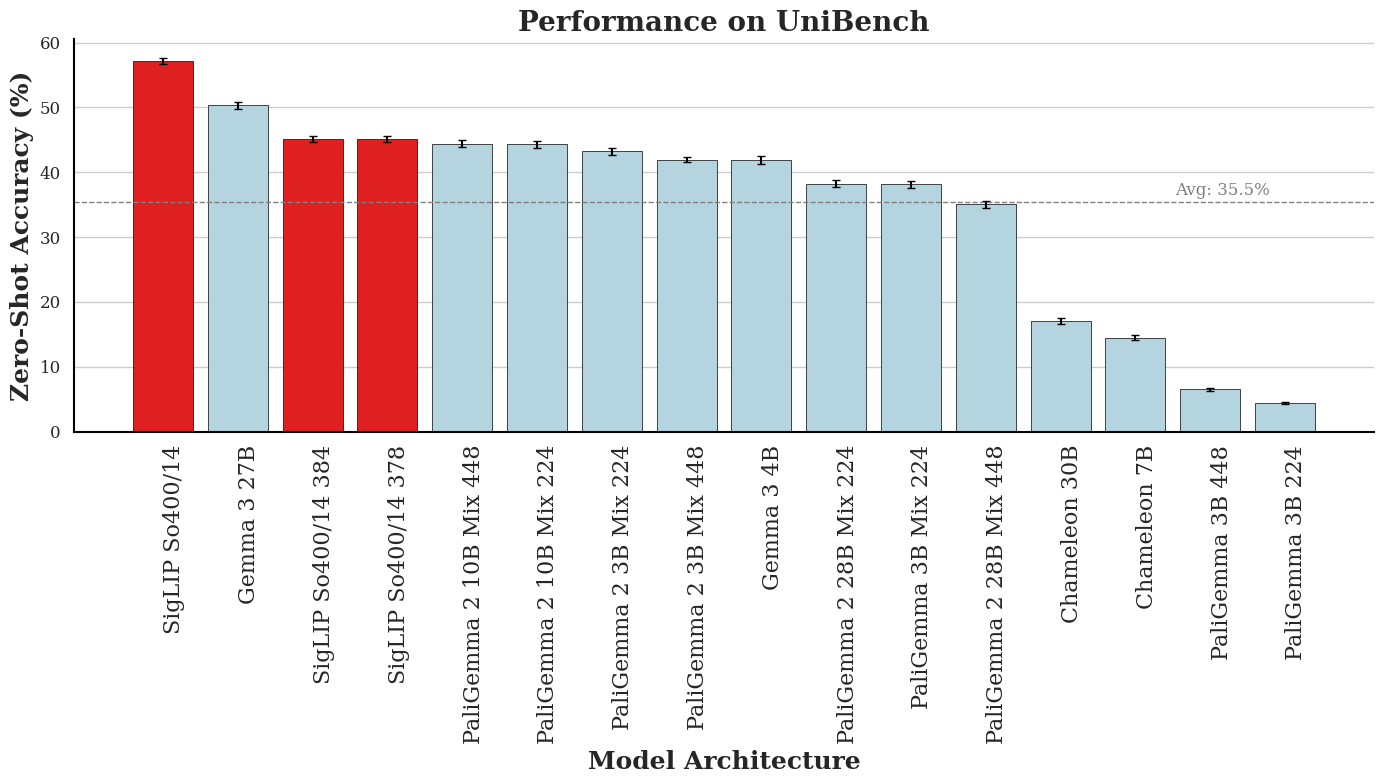

In [2]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.3 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


In [3]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['clip_vitL14', 'llama_3_2_11b_vision_instruct',
       'llava_1_5_13b', 'llava_1_5_7b', 'llava_1_6_mistral_7b',
       'llava_1_6_vicuna_13b', 'llava_1_6_vicuna_7b',
       'llava_next_llama_8b']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

/tmp/ipykernel_3044869/1979274884.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


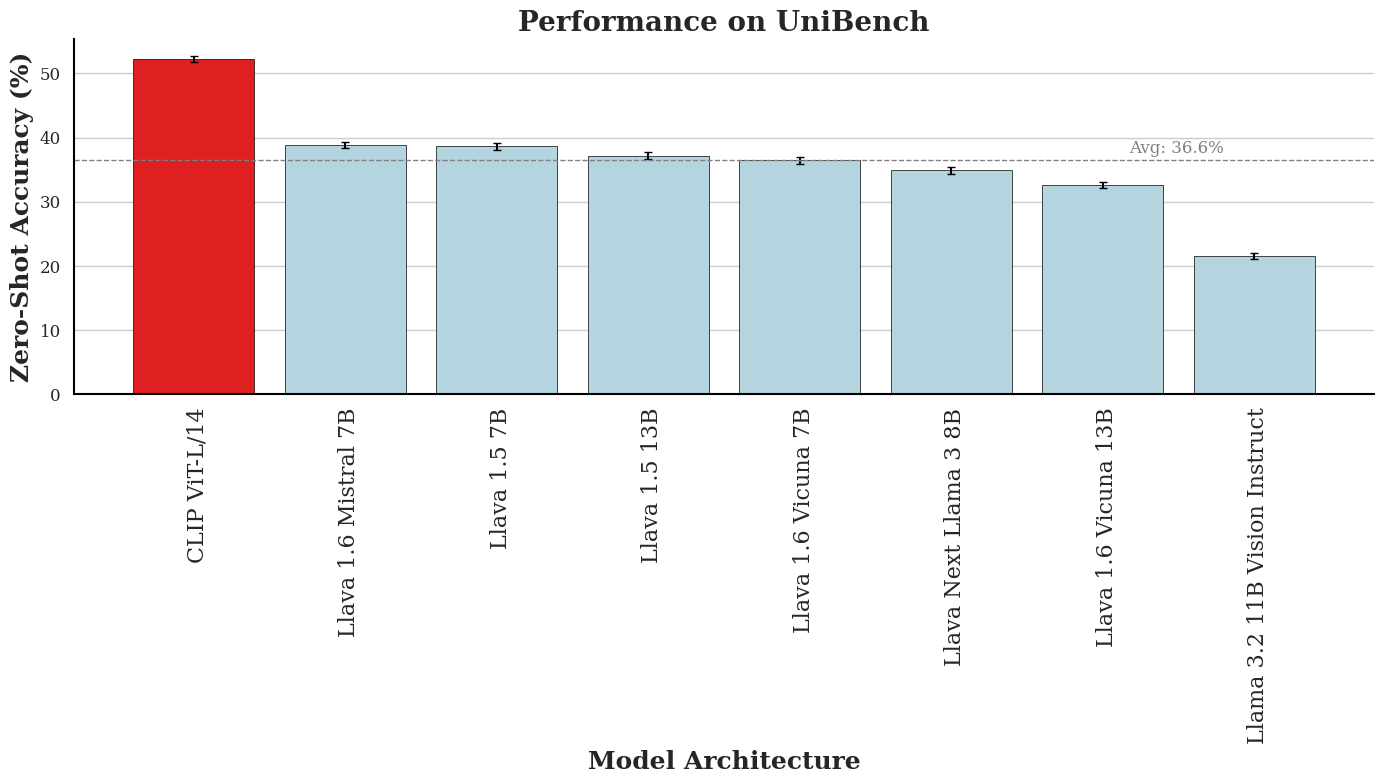

In [4]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'CLIP' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.1 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


In [12]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['eva01_vitG14_plus_2b','aya_vision_8b']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
from unibench.common_utils.utils import get_benchmark_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('EVA')) | (results['task_name'] == 'multi_choice_relation')]

/tmp/ipykernel_56253/698205941.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


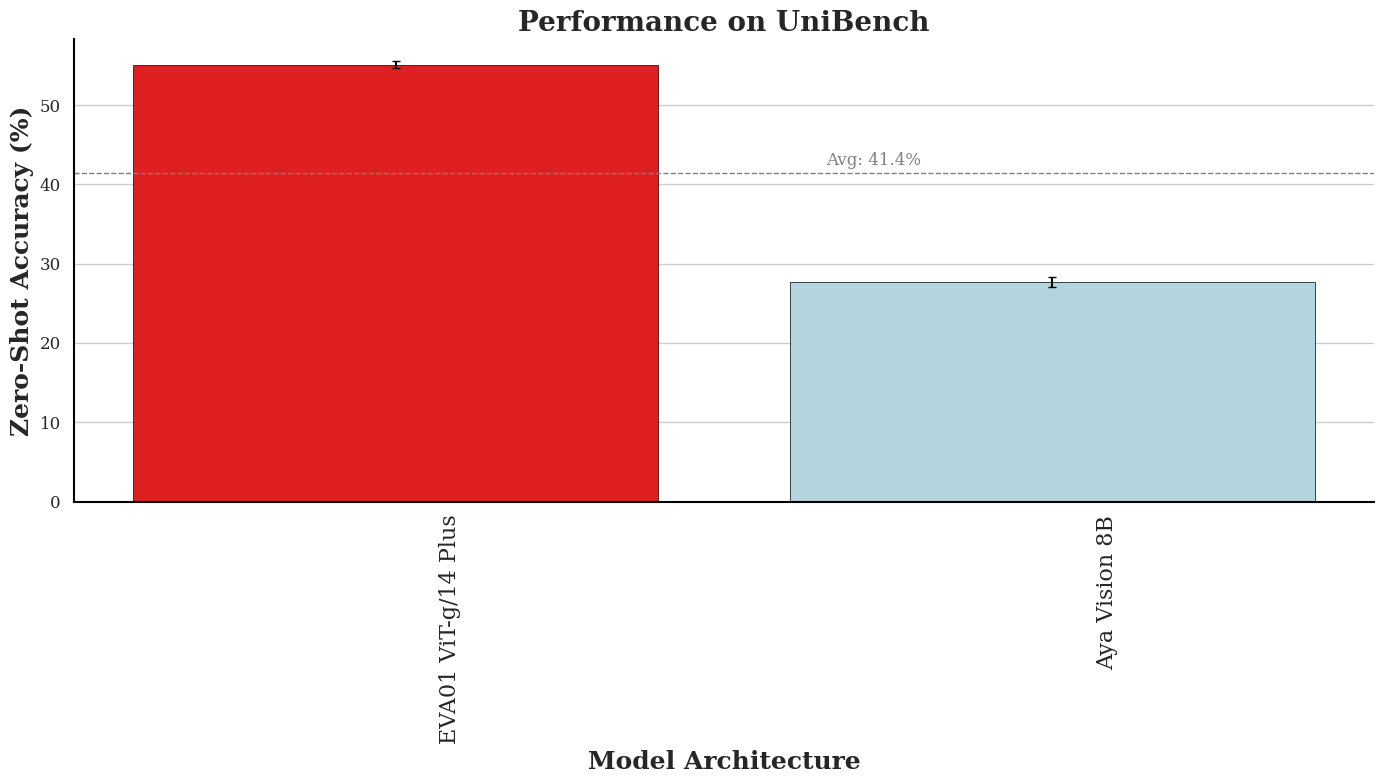

In [13]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'EVA' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.1 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


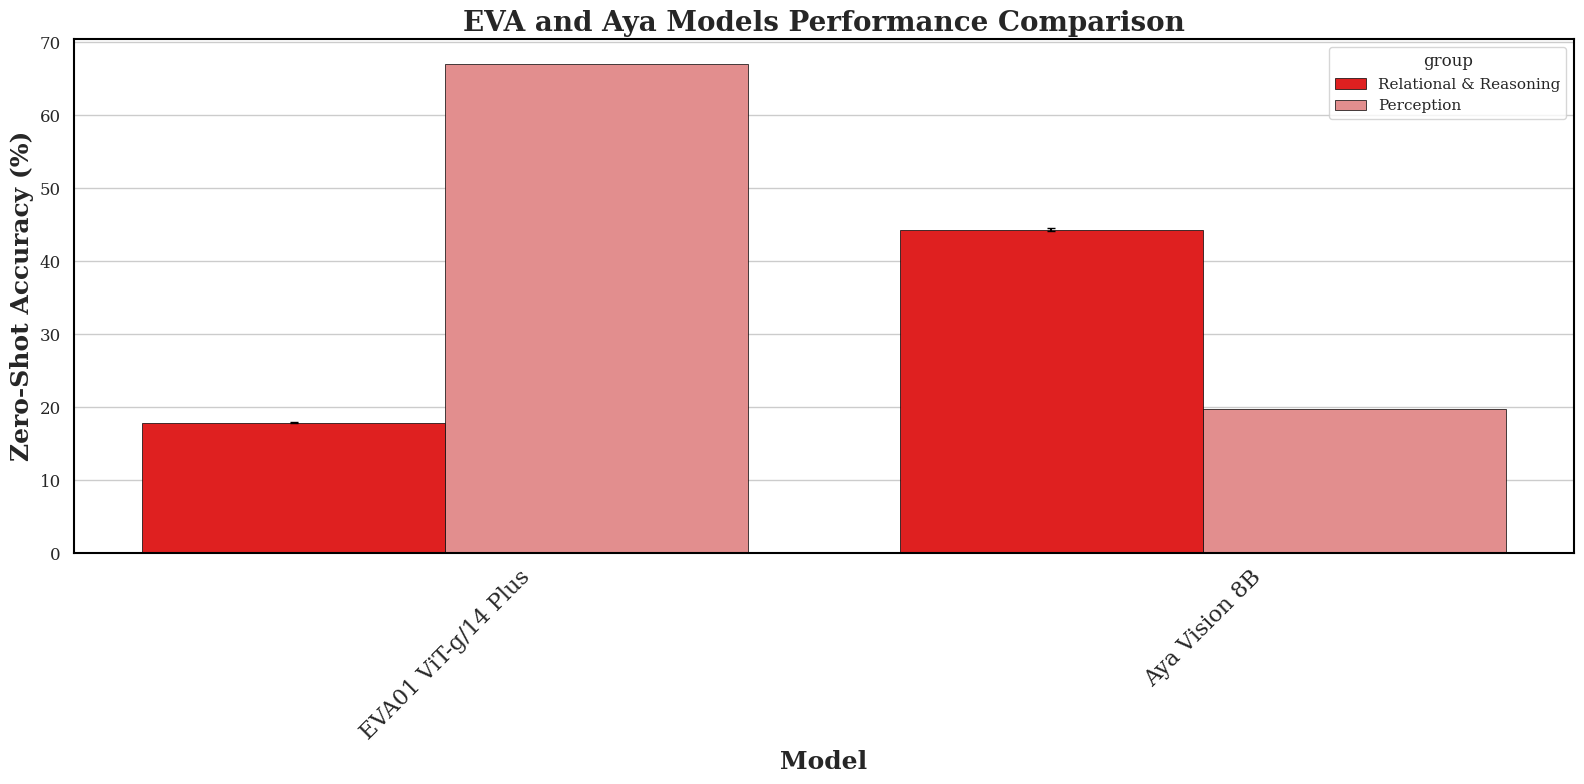

Performance Summary:

EVA Models:
  EVA01 ViT-g/14 Plus - Relational & Reasoning: 17.9% (±0.1%)
  EVA01 ViT-g/14 Plus - Perception: 67.1% (±0.0%)

Aya Models:
  Aya Vision 8B - Relational & Reasoning: 44.3% (±0.2%)
  Aya Vision 8B - Perception: 19.8% (±0.1%)


In [15]:
# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Filter data for EVA and Aya models
eva_data = results[results['model_name'].str.contains('EVA')]
aya_data = results[results['model_name'].str.contains('Aya')]

# Define benchmark type groups
relational_reasoning = ['relation', 'reasoning (counting)', 'reasoning (spatial)']
other_types = [bt for bt in benchmark_types if bt not in relational_reasoning]

# Function to compute performance for a group of benchmark types
def compute_group_performance(data, benchmark_type_list, group_name):
    filtered_data = data[data['benchmark_type'].isin(benchmark_type_list)]
    if len(filtered_data) == 0:
        return pd.DataFrame()
    
    performance = filtered_data.groupby("model_name").correctness.mean() * 100
    sem = filtered_data.groupby("model_name").correctness.sem() * 100
    
    return pd.DataFrame({
        'model_name': performance.index,
        'performance': performance.values,
        'sem': sem.values,
        'group': group_name
    })

# Compute performance for each group
eva_relational = compute_group_performance(eva_data, relational_reasoning, 'Relational & Reasoning')
eva_other = compute_group_performance(eva_data, other_types, 'Perception')
aya_relational = compute_group_performance(aya_data, relational_reasoning, 'Relational & Reasoning')
aya_other = compute_group_performance(aya_data, other_types, 'Perception')

# Combine data
eva_combined = pd.concat([eva_relational, eva_other], ignore_index=True)
aya_combined = pd.concat([aya_relational, aya_other], ignore_index=True)
# Compute performance for each group
eva_relational = compute_group_performance(eva_data, relational_reasoning, 'Relational & Reasoning')
eva_other = compute_group_performance(eva_data, other_types, 'Perception')
aya_relational = compute_group_performance(aya_data, relational_reasoning, 'Relational & Reasoning')
aya_other = compute_group_performance(aya_data, other_types, 'Perception')

# Add model type to distinguish EVA from Aya
eva_relational['model_type'] = 'EVA'
eva_other['model_type'] = 'EVA'
aya_relational['model_type'] = 'Aya'
aya_other['model_type'] = 'Aya'

# Combine all data
all_combined = pd.concat([eva_relational, eva_other, aya_relational, aya_other], ignore_index=True)

# Create single figure
plt.figure(figsize=(16, 8))

# Create bar plot with hue for both model type and group
ax = sns.barplot(data=all_combined, x='model_name', y='performance', 
                 hue='group', palette=['red', 'lightcoral'], 
                 edgecolor='black', linewidth=0.5)

# Add error bars manually
unique_models = all_combined['model_name'].unique()
for i, model in enumerate(unique_models):
    model_data = all_combined[all_combined['model_name'] == model]
    for j, group in enumerate(['Relational & Reasoning', 'Other']):
        group_data = model_data[model_data['group'] == group]
        if len(group_data) > 0:
            x_pos = i + (j - 0.5) * 0.4
            plt.errorbar(x_pos, group_data['performance'].values[0], 
                        yerr=group_data['sem'].values[0], 
                        fmt='none', color='black', capsize=3, elinewidth=1.5)

# Customize plot
ax.set_title('EVA and Aya Models Performance Comparison', fontsize=TITLE_FONT_SIZE, weight='bold')
ax.set_xlabel('Model', fontsize=LABEL_FONT_SIZE)
ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Performance Summary:")
print("\nEVA Models:")
for _, row in all_combined[all_combined['model_type'] == 'EVA'].iterrows():
    print(f"  {row['model_name']} - {row['group']}: {row['performance']:.1f}% (±{row['sem']:.1f}%)")

print("\nAya Models:")
for _, row in all_combined[all_combined['model_type'] == 'Aya'].iterrows():
    print(f"  {row['model_name']} - {row['group']}: {row['performance']:.1f}% (±{row['sem']:.1f}%)")


In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models('vllm') + ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'eva01_vitG14_plus_2b', 'clip_vitL14',]

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('SigLIP')) | (results['model_name'].str.contains('EVA')) |  (results['model_name'].str.contains('CLIP')) | (results['task_name'] == 'multi_choice_relation')]

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

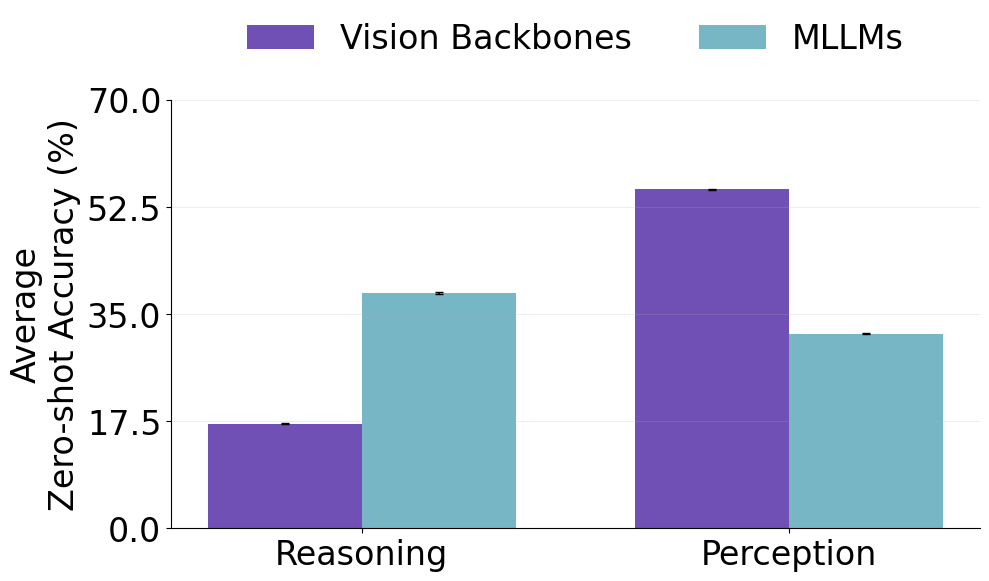

In [6]:
# --- Styling (from prompt) ---
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 24
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define vision backbone models and MLLMs
vision_backbone_models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'eva01_vitG14_plus_2b', 'clip_vitL14']
mllm_models = [model for model in models if model not in vision_backbone_models]

# Filter data for vision backbones and MLLMs
vision_data = results[results['model_name'].apply(lambda x: any(backbone in x for backbone in [model_mappings.get(model, model) for model in vision_backbone_models]))]
mllm_data = results[results['model_name'].apply(lambda x: any(mllm in x for mllm in [model_mappings.get(model, model) for model in mllm_models]))]

# Map benchmark names to categories using the benchmark_mappings
results['benchmark_category'] = results['benchmark_name'].map(benchmark_mappings)

# Define benchmark categories for relational reasoning
relational_reasoning = ['relation', 'reasoning (counting)', 'reasoning (spatial)']

# Function to compute performance for a group of benchmark categories
def compute_group_performance(data, benchmark_category_list, group_name):
    # Map benchmark names to categories for the filtered data
    data_with_categories = data.copy()
    data_with_categories['benchmark_category'] = data_with_categories['benchmark_name'].map(benchmark_mappings)
    
    # Filter by benchmark categories
    filtered = data_with_categories[data_with_categories['benchmark_category'].isin(benchmark_category_list)]
    if len(filtered) == 0:
        return pd.DataFrame(columns=['model_name', 'performance', 'sem', 'group'])
    perf = filtered.groupby("model_name").correctness.mean() * 100
    sem = filtered.groupby("model_name").correctness.sem() * 100
    return pd.DataFrame({
        'model_name': perf.index,
        'performance': perf.values,
        'sem': sem.values,
        'group': group_name
    })

# Compute performance for each group
vision_rel = compute_group_performance(vision_data, relational_reasoning, 'Reasoning')
vision_per = compute_group_performance(vision_data, [cat for cat in benchmark_mappings.values() if cat not in relational_reasoning], 'Perception')
mllm_rel = compute_group_performance(mllm_data, relational_reasoning, 'Reasoning')
mllm_per = compute_group_performance(mllm_data, [cat for cat in benchmark_mappings.values() if cat not in relational_reasoning], 'Perception')

# Add model type to distinguish Vision Backbones from MLLMs
for df in (vision_rel, vision_per):
    df['model_type'] = 'Vision Backbones'
for df in (mllm_rel, mllm_per):
    df['model_type'] = 'MLLMs'

# Combine all data
all_combined = pd.concat([vision_rel, vision_per, mllm_rel, mllm_per], ignore_index=True)

# Compute averages for each model type and group
avg_data = []
for model_type in ['Vision Backbones', 'MLLMs']:
    for group in ['Reasoning', 'Perception']:
        subset = all_combined[(all_combined['model_type'] == model_type) & (all_combined['group'] == group)]
        if len(subset) > 0:
            avg_perf = subset['performance'].mean()
            avg_sem = subset['sem'].mean()  # Average of SEMs
            avg_data.append({
                'model_type': model_type,
                'group': group,
                'performance': avg_perf,
                'sem': avg_sem
            })

plot_df = pd.DataFrame(avg_data)

# -------------- Plot (Matplotlib only; no seaborn) --------------
# Colors for model types
COLOR_VISION = '#7050B5'      # purple-ish for Vision Backbones
COLOR_MLLM = '#76B6C5'        # teal-ish for MLLMs
color_map = {'Vision Backbones': COLOR_VISION, 'MLLMs': COLOR_MLLM}

# X-axis groups and model types
groups = ['Reasoning', 'Perception']
model_types = ['Vision Backbones', 'MLLMs']

# Ensure both model types exist for each group
plot_df = (
    plot_df
    .set_index(['group', 'model_type'])
    .reindex(pd.MultiIndex.from_product([groups, model_types], names=['group', 'model_type']))
    .reset_index()
)

x = np.arange(len(groups), dtype=float)
bar_width = 0.36
offsets = {
    'Vision Backbones': -bar_width/2,
    'MLLMs': bar_width/2,
}

fig, ax = plt.subplots(figsize=(10, 6))

# Draw bars + error bars
for model_type in model_types:
    model_df = plot_df[plot_df['model_type'] == model_type]
    xpos = x + offsets[model_type]
    # Bars
    bars = ax.bar(
        xpos,
        model_df['performance'].values,
        width=bar_width,
        label=model_type,
        color=color_map[model_type],
        edgecolor='none'
    )
    # Error bars (only where SEM is finite)
    sem_vals = model_df['sem'].values
    ax.errorbar(
        xpos,
        model_df['performance'].values,
        yerr=sem_vals,
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=3
    )

# Style to match attached figure
ax.set_ylabel('Average\nZero-shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
ax.set_xlabel('', fontsize=LABEL_FONT_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=TICK_FONT_SIZE)
ax.tick_params(axis='y', labelsize=TICK_FONT_SIZE)

# Light y-grid; remove top/right spines
ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Nice y-limits / ticks like the attached (0 → nice max with ~4 intervals)
ymax = np.nanmax(plot_df['performance'].values) if len(plot_df) else 100
upper = (np.ceil((ymax+5)/10)*10)  # round up to nearest 10
ax.set_ylim(0, upper)
ax.set_yticks(np.linspace(0, upper, 5))

# Title & legend
leg = ax.legend(frameon=False, fontsize=TICK_FONT_SIZE, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.25))

plt.tight_layout()
plt.show()


In [4]:
relational_reasoning


['relation', 'reasoning (counting)', 'reasoning (spatial)']

In [12]:
sig_models = ['siglip_so400_14', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']
clip_models = ['clip_vitL14', 'llama_3_2_11b_vision_instruct',
       'llava_1_5_13b', 'llava_1_5_7b', 'llava_1_6_mistral_7b',
       'llava_1_6_vicuna_13b', 'llava_1_6_vicuna_7b',
       'llava_next_llama_8b']
eva_models = ['eva01_vitG14_plus_2b','aya_vision_32b', 'aya_vision_8b']

import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list(set(sig_models + clip_models + eva_models))

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)



File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f


In [13]:
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
sig_results = results[results['model_name'].isin(sig_models)]
clip_results = results[results['model_name'].isin(clip_models)]
eva_results = results[results['model_name'].isin(eva_models)]

from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

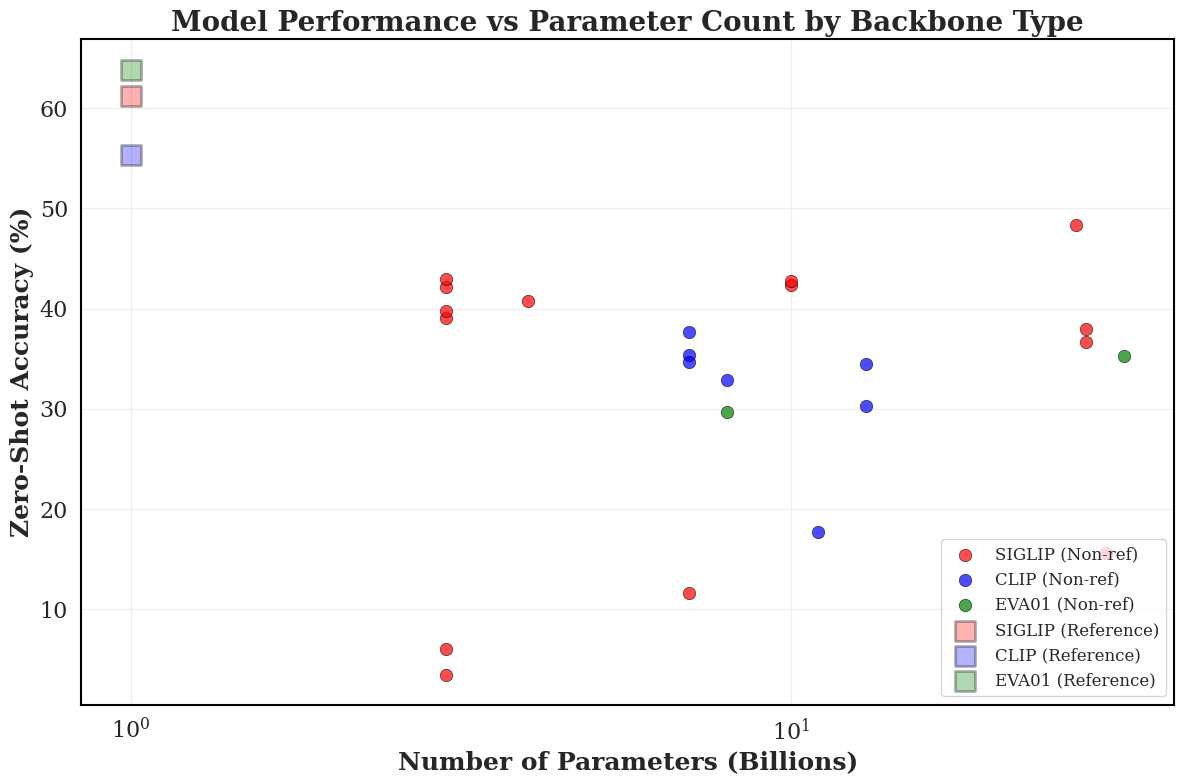

Parameter Count vs Performance Analysis:

SIGLIP:
  Reference: SigLIP So400/14 - 1B params, 61.2% performance
  Parameter range: 3-30B
  Performance range: 3.5-48.3%
  Correlation (log params vs performance): 0.157

CLIP:
  Reference: CLIP ViT-L/14 - 1B params, 55.4% performance
  Parameter range: 7-13B
  Performance range: 17.7-37.7%
  Correlation (log params vs performance): -0.485

EVA01:
  Reference: EVA01 ViT-g/14 Plus - 1B params, 63.8% performance
  Parameter range: 8-32B
  Performance range: 29.7-35.3%


In [15]:
import numpy as np
from matplotlib.patches import Patch

# Create scatter plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Combine all differences into one dataframe
all_diffs = pd.concat([sig_diff, clip_diff, eva_diff], ignore_index=True)

# Add parameter count extraction function
def extract_param_count(model_name):
    """Extract parameter count from model name (in billions)"""
    name_lower = model_name.lower()
    
    # Look for common parameter patterns
    if '30b' in name_lower:
        return 30
    elif '28b' in name_lower:
        return 28
    elif '27b' in name_lower:
        return 27
    elif '32b' in name_lower:
        return 32
    elif '13b' in name_lower:
        return 13
    elif '11b' in name_lower:
        return 11
    elif '10b' in name_lower:
        return 10
    elif '8b' in name_lower:
        return 8
    elif '7b' in name_lower:
        return 7
    elif '4b' in name_lower:
        return 4
    elif '3b' in name_lower:
        return 3
    elif '2b' in name_lower:
        return 2
    else:
        return 1  # Default for models without clear parameter count

# Add parameter counts to the data
all_diffs = all_diffs.copy()
all_diffs['param_count'] = all_diffs['model_name'].apply(extract_param_count)

# Define colors for each category
colors_dict = {'SIGLIP': 'red', 'CLIP': 'blue', 'EVA01': 'green'}

# Separate reference and non-reference models
reference_models = all_diffs[all_diffs['difference_from_reference'] == 0]
non_reference_models = all_diffs[all_diffs['difference_from_reference'] != 0]

# Plot non-reference models as regular scatter points
for category in colors_dict.keys():
    cat_data = non_reference_models[non_reference_models['category'] == category]
    if len(cat_data) > 0:
        ax.scatter(cat_data['param_count'], cat_data['performance'], 
                  c=colors_dict[category], alpha=0.7, s=80, 
                  label=f'{category} (Non-ref)', edgecolors='black', linewidth=0.5)

# Plot reference models with special shading/styling
for category in colors_dict.keys():
    cat_data = reference_models[reference_models['category'] == category]
    if len(cat_data) > 0:
        ax.scatter(cat_data['param_count'], cat_data['performance'], 
                  c=colors_dict[category], alpha=0.3, s=200, 
                  marker='s', label=f'{category} (Reference)', 
                  edgecolors='black', linewidth=2)

# Set x-axis to log scale
ax.set_xscale('log')
ax.set_xlabel('Number of Parameters (Billions)', fontsize=LABEL_FONT_SIZE, weight='bold')
ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE, weight='bold')
ax.set_title('Model Performance vs Parameter Count by Backbone Type', 
             fontsize=TITLE_FONT_SIZE, weight='bold')

# Customize grid and ticks
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)

# Add legend
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Parameter Count vs Performance Analysis:")
for category in colors_dict.keys():
    cat_data = all_diffs[all_diffs['category'] == category]
    if len(cat_data) > 0:
        ref_data = cat_data[cat_data['difference_from_reference'] == 0]
        non_ref_data = cat_data[cat_data['difference_from_reference'] != 0]
        
        print(f"\n{category}:")
        if len(ref_data) > 0:
            print(f"  Reference: {ref_data.iloc[0]['model_name']} - {ref_data.iloc[0]['param_count']}B params, {ref_data.iloc[0]['performance']:.1f}% performance")
        if len(non_ref_data) > 0:
            print(f"  Parameter range: {non_ref_data['param_count'].min()}-{non_ref_data['param_count'].max()}B")
            print(f"  Performance range: {non_ref_data['performance'].min():.1f}-{non_ref_data['performance'].max():.1f}%")
            
            # Correlation analysis
            if len(non_ref_data) > 2:
                correlation = np.corrcoef(np.log(non_ref_data['param_count']), non_ref_data['performance'])[0,1]
                print(f"  Correlation (log params vs performance): {correlation:.3f}")


In [9]:
# Calculate performance for each category
def calculate_performance_diff(category_results, reference_model_key, category_models):
    if len(category_results) == 0:
        return pd.DataFrame()
    
    # Calculate mean performance for each model using original model names
    performance = category_results.groupby("model_name").correctness.mean() * 100
    
    # Get reference performance using original model name
    if reference_model_key in performance.index:
        reference_perf = performance[reference_model_key]
        
        # Calculate differences
        differences = performance - reference_perf
        
        # Map to display names for output
        mapped_names = [model_mappings.get(name, name) for name in differences.index]
        
        return pd.DataFrame({
            'model_name': mapped_names,
            'performance': performance.values,
            'difference_from_reference': differences.values,
            'category': [reference_model_key.split('_')[0].upper()] * len(differences)
        })
    else:
        return pd.DataFrame()

# Calculate differences for each category
sig_diff = calculate_performance_diff(sig_results, sig_models[0], sig_models)
clip_diff = calculate_performance_diff(clip_results, clip_models[0], clip_models) 
eva_diff = calculate_performance_diff(eva_results, eva_models[0], eva_models)

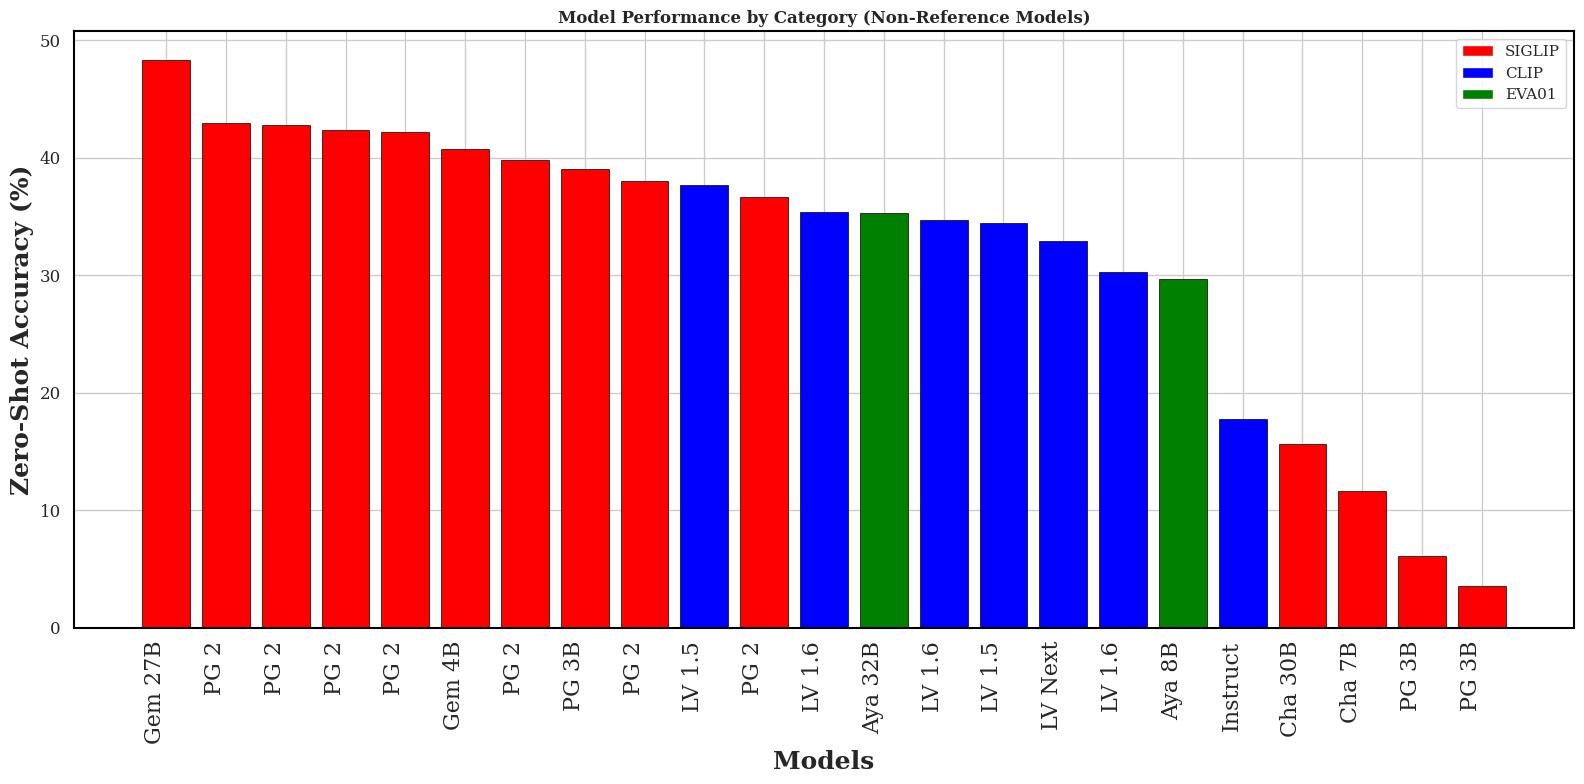

Performance Summary by Category (Non-Reference Models):

SIGLIP:
  Best performing: Gemma 3 27B (48.3%)
  Average performance: 32.1%
  Number of models: 14

CLIP:
  Best performing: Llava 1.5 7B (37.7%)
  Average performance: 31.9%
  Number of models: 7

EVA01:
  Best performing: Aya Vision 32B (35.3%)
  Average performance: 32.5%
  Number of models: 2


In [10]:
from matplotlib.patches import Patch

# Create a single plot showing absolute performance
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Combine all differences into one dataframe
all_diffs = pd.concat([sig_diff, clip_diff, eva_diff], ignore_index=True)

# Remove reference models (those with difference_from_reference = 0)
non_reference_data = all_diffs[all_diffs['difference_from_reference'] != 0]

# Sort by performance for better visualization
sorted_data = non_reference_data.sort_values('performance', ascending=False)

# Define colors for each category
colors_dict = {'SIGLIP': 'red', 'CLIP': 'blue', 'EVA01': 'green'}
model_colors = [colors_dict[cat] for cat in sorted_data['category']]

# Plot: Absolute Performance
bars = ax.bar(range(len(sorted_data)), sorted_data['performance'], 
               color=model_colors, edgecolor='black', linewidth=0.5)

ax.set_title('Model Performance by Category (Non-Reference Models)', weight='bold')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_xlabel('Models')

# Simplify x-axis labels
simplified_names = []
for name in sorted_data['model_name']:
    if 'PaliGemma' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"PG {parts[1]}")
        else:
            simplified_names.append(name[:10])
    elif 'Llava' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"LV {parts[1]}")
        else:
            simplified_names.append(name[:10])
    elif 'Chameleon' in name or 'Gemma' in name or 'Aya' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"{parts[0][:3]} {parts[-1]}")
        else:
            simplified_names.append(name[:10])
    else:
        simplified_names.append(name.split()[-1] if ' ' in name else name[:12])

ax.set_xticks(range(len(sorted_data)))
ax.set_xticklabels(simplified_names, rotation=90, ha='right')

# Add legend
categories = sorted_data['category'].unique()
legend_elements = [Patch(facecolor=colors_dict[cat], label=cat) for cat in categories]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Performance Summary by Category (Non-Reference Models):")
for category in categories:
    cat_data = sorted_data[sorted_data['category'] == category]
    if len(cat_data) > 0:
        print(f"\n{category}:")
        print(f"  Best performing: {cat_data.loc[cat_data['performance'].idxmax(), 'model_name']} ({cat_data['performance'].max():.1f}%)")
        print(f"  Average performance: {cat_data['performance'].mean():.1f}%")
        print(f"  Number of models: {len(cat_data)}")


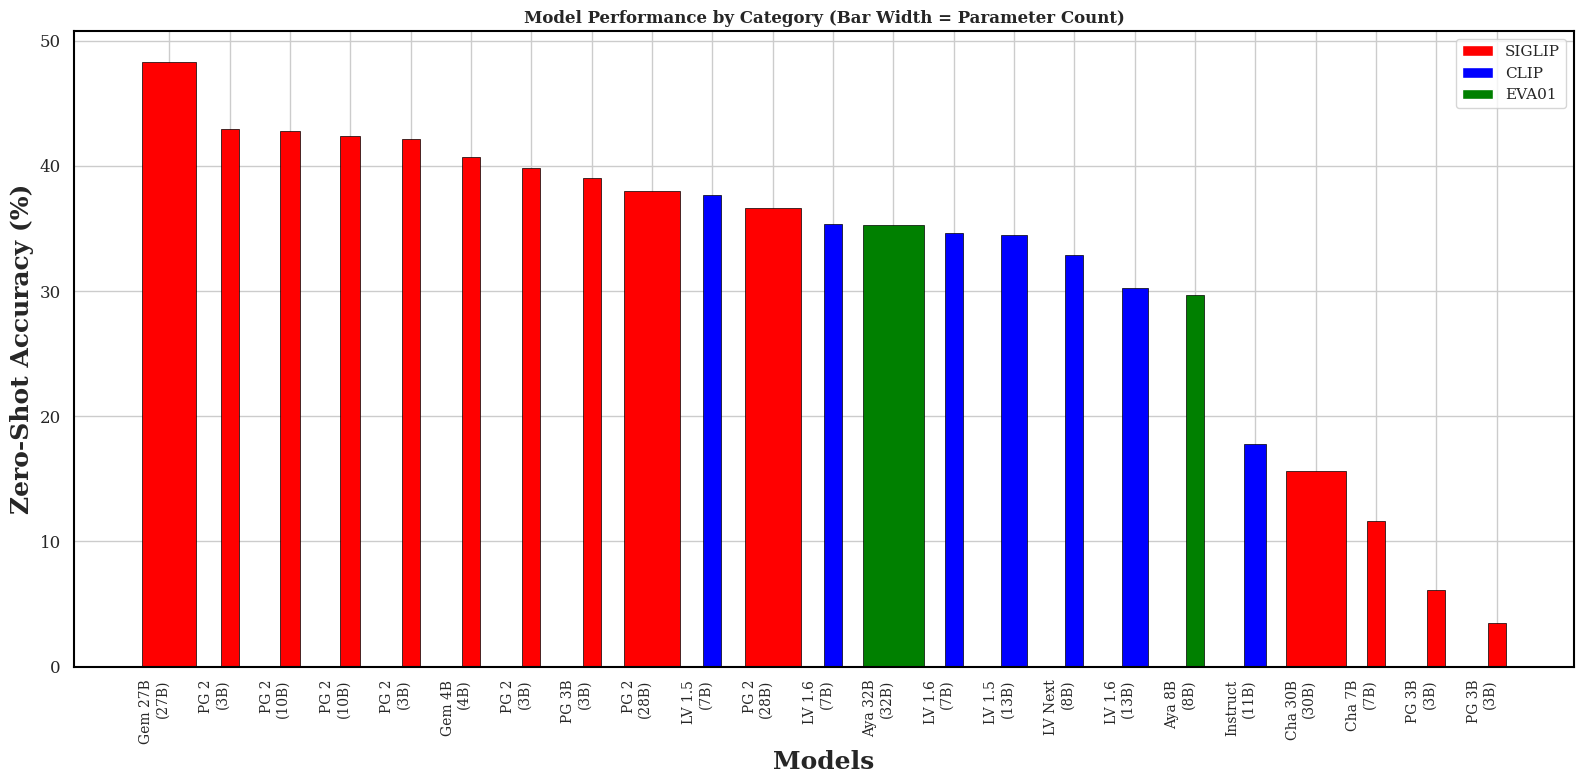

Performance Summary by Category (Controlling for Parameter Count):

SIGLIP:
  Best performing: Gemma 3 27B (48.3%)
  Average performance: 32.1%
  Parameter range: 3-30B
  Performance per billion parameters: 2.78%/B
  Number of models: 14

CLIP:
  Best performing: Llava 1.5 7B (37.7%)
  Average performance: 31.9%
  Parameter range: 7-13B
  Performance per billion parameters: 3.38%/B
  Number of models: 7

EVA01:
  Best performing: Aya Vision 32B (35.3%)
  Average performance: 32.5%
  Parameter range: 8-32B
  Performance per billion parameters: 1.62%/B
  Number of models: 2

Parameter Efficiency Ranking:
  PaliGemma 2 3B Mix 448: 14.30%/B (42.9% with 3B params)
  PaliGemma 2 3B Mix 224: 14.06%/B (42.2% with 3B params)
  PaliGemma 2 3B Mix 448: 13.27%/B (39.8% with 3B params)
  PaliGemma 3B Mix 224: 13.01%/B (39.0% with 3B params)
  Gemma 3 4B: 10.18%/B (40.7% with 4B params)
  Llava 1.5 7B: 5.38%/B (37.7% with 7B params)
  Llava 1.6 Mistral 7B: 5.05%/B (35.4% with 7B params)
  Llava 1.6 

In [11]:
from matplotlib.patches import Patch

# Create a single plot showing absolute performance
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Combine all differences into one dataframe
all_diffs = pd.concat([sig_diff, clip_diff, eva_diff], ignore_index=True)

# Remove reference models (those with difference_from_reference = 0)
non_reference_data = all_diffs[all_diffs['difference_from_reference'] != 0]

# Add parameter count extraction function
def extract_param_count(model_name):
    """Extract parameter count from model name (in billions)"""
    name_lower = model_name.lower()
    
    # Look for common parameter patterns
    if '30b' in name_lower:
        return 30
    elif '28b' in name_lower:
        return 28
    elif '27b' in name_lower:
        return 27
    elif '32b' in name_lower:
        return 32
    elif '13b' in name_lower:
        return 13
    elif '11b' in name_lower:
        return 11
    elif '10b' in name_lower:
        return 10
    elif '8b' in name_lower:
        return 8
    elif '7b' in name_lower:
        return 7
    elif '4b' in name_lower:
        return 4
    elif '3b' in name_lower:
        return 3
    elif '2b' in name_lower:
        return 2
    else:
        return 0  # Unknown parameter count

# Add parameter counts to the data
non_reference_data = non_reference_data.copy()
non_reference_data['param_count'] = non_reference_data['model_name'].apply(extract_param_count)

# Sort by performance for better visualization
sorted_data = non_reference_data.sort_values('performance', ascending=False)

# Define colors for each category
colors_dict = {'SIGLIP': 'red', 'CLIP': 'blue', 'EVA01': 'green'}
model_colors = [colors_dict[cat] for cat in sorted_data['category']]

# Plot: Absolute Performance with parameter count as bar width
bars = ax.bar(range(len(sorted_data)), sorted_data['performance'], 
               color=model_colors, edgecolor='black', linewidth=0.5,
               width=[max(0.3, min(1.0, p/30)) for p in sorted_data['param_count']])

ax.set_title('Model Performance by Category (Bar Width = Parameter Count)', weight='bold')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_xlabel('Models')

# Simplify x-axis labels with parameter count
simplified_names = []
for idx, row in sorted_data.iterrows():
    name = row['model_name']
    param_count = row['param_count']
    
    if 'PaliGemma' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"PG {parts[1]}\n({param_count}B)")
        else:
            simplified_names.append(f"{name[:10]}\n({param_count}B)")
    elif 'Llava' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"LV {parts[1]}\n({param_count}B)")
        else:
            simplified_names.append(f"{name[:10]}\n({param_count}B)")
    elif 'Chameleon' in name or 'Gemma' in name or 'Aya' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"{parts[0][:3]} {parts[-1]}\n({param_count}B)")
        else:
            simplified_names.append(f"{name[:10]}\n({param_count}B)")
    else:
        label = name.split()[-1] if ' ' in name else name[:12]
        simplified_names.append(f"{label}\n({param_count}B)")

ax.set_xticks(range(len(sorted_data)))
ax.set_xticklabels(simplified_names, rotation=90, ha='right', fontsize=10)

# Add legend
categories = sorted_data['category'].unique()
legend_elements = [Patch(facecolor=colors_dict[cat], label=cat) for cat in categories]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics with parameter count analysis
print("Performance Summary by Category (Controlling for Parameter Count):")
for category in categories:
    cat_data = sorted_data[sorted_data['category'] == category]
    if len(cat_data) > 0:
        print(f"\n{category}:")
        print(f"  Best performing: {cat_data.loc[cat_data['performance'].idxmax(), 'model_name']} ({cat_data['performance'].max():.1f}%)")
        print(f"  Average performance: {cat_data['performance'].mean():.1f}%")
        print(f"  Parameter range: {cat_data['param_count'].min()}-{cat_data['param_count'].max()}B")
        print(f"  Performance per billion parameters: {cat_data['performance'].mean() / cat_data['param_count'].mean():.2f}%/B")
        print(f"  Number of models: {len(cat_data)}")

# Performance efficiency analysis
print("\nParameter Efficiency Ranking:")
efficiency_data = sorted_data[sorted_data['param_count'] > 0].copy()
efficiency_data['efficiency'] = efficiency_data['performance'] / efficiency_data['param_count']
efficiency_ranking = efficiency_data.sort_values('efficiency', ascending=False)

for idx, row in efficiency_ranking.head(10).iterrows():
    print(f"  {row['model_name']}: {row['efficiency']:.2f}%/B ({row['performance']:.1f}% with {row['param_count']}B params)")
